In [1]:
#import packages
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, image
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

## Subject Parameters

In [2]:
BASE_DIR     = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")
SUBJECT      = 100206
TASK         = "GAMBLING"    # 또는 "EMOTION"
PHASE        = "LR"          # "LR" 또는 "RL"

In [3]:
aal = datasets.fetch_atlas_aal()
aal_img    = aal.maps    # AAL atlas NIfTI 경로
aal_labels = aal.labels  # ROI 이름 리스트

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [4]:
masker    = NiftiLabelsMasker(
    labels_img       = aal_img,
    standardize      = "zscore_sample",
    detrend          = True,
    low_pass         = None,
    high_pass        = None,
    t_r              = 0.72,
    resampling_target = "data"
)

In [5]:
def make_paths(subject, task, phase="LR"):
    img_path = BASE_DIR / f"{subject:06d}/MNINonLinear/Results/tfMRI_{task}_{phase}/tfMRI_{task}_{phase}.nii.gz"
    ev_dir   = img_path.parent / "EVs"
    return img_path, ev_dir

In [ ]:
def get_residual(img_path: Path, ev_dir: Path):
    """
    EVs 폴더 내의 *.txt 파일들을 건너뛰기 로직과 함께 읽어서
    onset/duration 정보를 모은 뒤, FirstLevelModel로 GLM을 수행한 후
    residual 4D 이미지를 반환합니다.
    """
    events = []

    for ev_file in sorted(ev_dir.glob("*.txt")):
        # 1) 순수히 숫자가 아닌 파일은 건너뛰기
        try:
            data = np.loadtxt(ev_file)
        except Exception:
            continue

        # 2) 빈 파일 혹은 숫자가 0개라면 건너뜀
        if data.size == 0:
            continue

        # 3) 1차원 배열(단일 행)인 경우, 열 개수 확인
        if data.ndim == 1:
            if data.shape[0] < 2:
                # onset/duration 정보를 담기 어렵다면 건너뜀
                continue
            data = data.reshape(1, -1)

        # 4) 2차원 배열(여러 행)인 경우, 열 개수가 2 또는 3인지 확인
        if data.ndim == 2:
            n_cols = data.shape[1]
            if n_cols not in (2, 3):
                continue
        else:
            # ndim이 0 또는 3 이상이면 건너뜀
            continue

        # 5) 최종적으로 data가 (N_events, 2) 혹은 (N_events, 3) 모양으로 보장됨
        if data.shape[1] == 3:
            onset_arr, duration_arr, _ = data.T
        else:  # data.shape[1] == 2
            onset_arr, duration_arr = data.T

        for o, d in zip(onset_arr, duration_arr):
            events.append({
                "onset":      float(o),
                "duration":   float(d),
                "trial_type": ev_file.stem
            })

    # 만약 events 리스트가 비어 있으면 None 반환
    if not events:
        return None

    # 이벤트가 모였다면 DataFrame으로 정리하고 GLM → residual 반환
    events_df = pd.DataFrame(events, columns=["onset", "duration", "trial_type"])
    fmri_img  = image.load_img(str(img_path))
    model     = FirstLevelModel(
        t_r              = 0.72,
        drift_model      = "polynomial",
        standardize      = False,
        minimize_memory  = False
    ).fit(fmri_img, events=events_df)

    return model.residuals[0]  # list이므로 첫 번째 residual 4D 이미지 반환


In [7]:
def sliding_window_dist(ts: np.ndarray, win: int, step: int) -> np.ndarray:
    """
    ts: (T, P) shaped array, T = time points, P = number of ROIs
    win: window length in TRs
    step: sliding step in TRs

    반환값: (n_windows, P, P) shaped array of 1 - |correlation| distance matrices
    """
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P        = ts.shape
    n_windows   = (T - win) // step + 1
    out         = np.zeros((n_windows, P, P), dtype=np.float32)

    for idx, start in enumerate(range(0, T - win + 1, step)):
        segment      = ts[start : start + win]
        corr_matrix  = connectivity.fit_transform([segment])[0]
        dist_matrix  = 1.0 - np.abs(corr_matrix)
        out[idx]     = dist_matrix

    return out

In [8]:
img_path, ev_dir = make_paths(SUBJECT, TASK, PHASE)
print(f"Loading {TASK} {PHASE} run from: {img_path}")

Loading GAMBLING LR run from: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\100206\MNINonLinear\Results\tfMRI_GAMBLING_LR\tfMRI_GAMBLING_LR.nii.gz


In [9]:
resid_img = get_residual(img_path, ev_dir)
if resid_img is None:
    raise RuntimeError(f"No usable EV files found for {TASK} {PHASE} run.")

c:\Users\JINHWA\miniconda3\envs\tda\Lib\site-packages\nilearn\glm\first_level\first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [10]:
ts_resid = masker.fit_transform(resid_img)   # shape = (T, n_rois)
T, n_rois = ts_resid.shape
print(f"Extracted time-series shape: {ts_resid.shape}")

Extracted time-series shape: (253, 116)


## Window Parameters

In [ ]:
WINDOW_SIZE  = 28            # TR 단위
STEP_SIZE    = 2             # TR 단위

In [12]:
TR = 0.72
total_duration = T * TR
print(f"fMRI 총 길이: {T} TR ≈ {total_duration:.2f}초")

fMRI 총 길이: 253 TR ≈ 182.16초


In [13]:
def load_task_blocks(ev_dir, task, include_neutral=True):
    """
    ev_dir: EV 파일들이 들어있는 디렉터리 경로 (예: "C:/HCP/100206/tfMRI_GAMBLING_LR/EVs")
    task: "emotion" 또는 "gambling"
    include_neutral: True면 neutral 파일도 읽고, False면 neutral 파일 제외

    반환: [(label, onset_sec, duration_sec), ...] 형태의 리스트 (onset 기준 오름차순 정렬)
    """
    blocks = []

    if task.lower() == "emotion":
        mapping = {"fear": "fear.txt"}
        if include_neutral:
            mapping["neutral"] = "neut.txt"
        dur = 18.0

    elif task.lower() == "gambling":
        mapping = {"loss": "loss.txt", "win": "win.txt"}
        if include_neutral:
            mapping["neutral"] = "neut_event.txt"
        dur = 28.0

    else:
        raise ValueError(f"지원되지 않는 task: {task}")

    for label, fname in mapping.items():
        path = os.path.join(ev_dir, fname)
        if not os.path.isfile(path):
            raise FileNotFoundError(f"EV 파일이 없습니다: {path}")
        onsets = np.loadtxt(path)[:, 0]
        for t in onsets:
            blocks.append((label, float(t), dur))

    # onset 기준 정렬
    blocks.sort(key=lambda x: x[1])
    return blocks


In [14]:
gambling_ev_dir = f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset/{SUBJECT:06d}/MNINonLinear/Results/tfMRI_{TASK}_LR/EVs"
gambling_blocks = load_task_blocks(gambling_ev_dir, "gambling", include_neutral=False)
print(">> Gambling blocks:")
for lbl, onset, dur in gambling_blocks:
    print(f"{lbl:8s} | onset = {onset:7.3f} s | dur = {dur:.1f} s")

>> Gambling blocks:
loss     | onset =   8.063 s | dur = 28.0 s
win      | onset =  51.951 s | dur = 28.0 s
loss     | onset =  95.840 s | dur = 28.0 s
win      | onset = 139.742 s | dur = 28.0 s


In [15]:
gambling_blocks

[('loss', 8.063, 28.0),
 ('win', 51.951, 28.0),
 ('loss', 95.84, 28.0),
 ('win', 139.742, 28.0)]

In [16]:
# ───────────────
# 1. Compute block TR range
# ───────────────
events = []
for label, onset, duration in gambling_blocks:

    start_tr = int(np.floor(onset / TR))
    end_tr   = int(np.ceil((onset + duration) / TR)) - 1
    events.append({
        "trial_type": label,
        "onset_sec":  onset,
        "duration_s": duration,
        "start_tr":   start_tr,
        "end_tr":     end_tr
    })

ev_df = pd.DataFrame(events)
print("\n=== BLOCKS ===")
print(ev_df[["trial_type", "start_tr", "end_tr"]].to_string(index=False))

# ───────────────
# 2. Sliding Window Labeling
# ───────────────

n_windows = (T - WINDOW_SIZE) // STEP_SIZE + 1

window_labels = []
for t in range(n_windows):
    center_tr = t * STEP_SIZE + (WINDOW_SIZE // 2)
    hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
    window_labels.append(hit.iloc[0]["trial_type"] if not hit.empty else "no_event")

win_df = pd.DataFrame({
    "window_index": np.arange(n_windows),
    "center_tr":    np.arange(n_windows) * STEP_SIZE + (WINDOW_SIZE // 2),
    "block_label":  window_labels
})

print("\n=== WINDOW LABELS ===")
print(win_df.to_string(index=False))


=== BLOCKS ===
trial_type  start_tr  end_tr
      loss        11      50
       win        72     111
      loss       133     171
       win       194     232

=== WINDOW LABELS ===
 window_index  center_tr block_label
            0         15        loss
            1         17        loss
            2         19        loss
            3         21        loss
            4         23        loss
            5         25        loss
            6         27        loss
            7         29        loss
            8         31        loss
            9         33        loss
           10         35        loss
           11         37        loss
           12         39        loss
           13         41        loss
           14         43        loss
           15         45        loss
           16         47        loss
           17         49        loss
           18         51    no_event
           19         53    no_event
           20         55    no_event
  

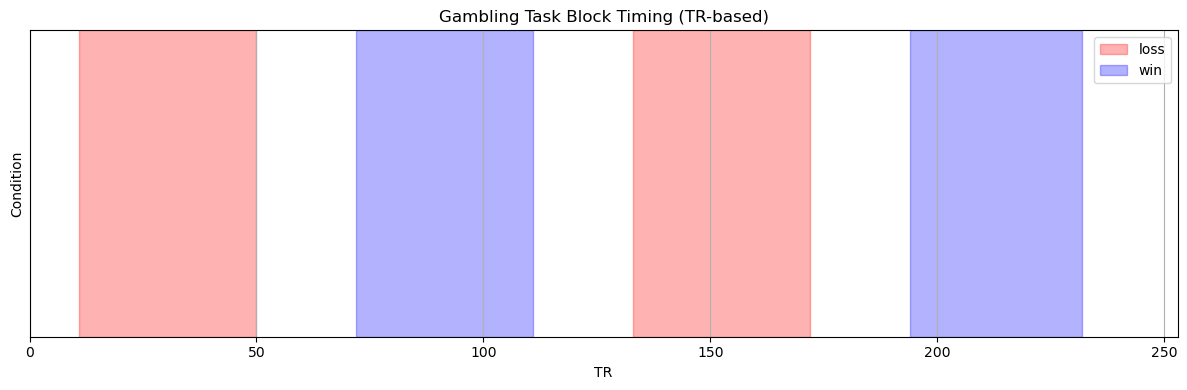

In [17]:
# Convert to TR-based onsets 
corrected_blocks = []
for label, onset, duration in gambling_blocks:

    start_tr = int(onset // TR)
    end_tr   = int((onset + duration) // TR)
    corrected_blocks.append((label, start_tr, end_tr))

# Plot
plt.figure(figsize=(12, 4))
for label, start_tr, end_tr in corrected_blocks:
    if label == 'loss': color = 'red' 
    elif label == 'win': color = 'blue'
    alpha = 0.3
    label_name = label if label not in plt.gca().get_legend_handles_labels()[1] else None
    plt.axvspan(start_tr, end_tr, color=color, alpha=alpha, label=label_name)

plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Gambling Task Block Timing (TR-based)")
plt.xlim(0, 253)  # full run duration
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
dist_tensor = sliding_window_dist(ts_resid, WINDOW_SIZE, STEP_SIZE)
print(f"Distance tensor shape: {dist_tensor.shape}")

Distance tensor shape: (112, 116, 116)


In [19]:
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts")
OUT_DIR.mkdir(exist_ok=True)

In [20]:
out_path = OUT_DIR / f"{SUBJECT}_{TASK}_{PHASE}_AAL_resid_abs_dist.npy"
np.save(out_path, dist_tensor)
print(f"Saved → {out_path}")

Saved → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\tfMRI_ts\100206_GAMBLING_LR_AAL_resid_abs_dist.npy


In [21]:
OUT_DIR = Path(f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_gambling_dist")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [22]:
for i, mat in enumerate(dist_tensor):
    # 파일명 예시: rs100206_dist_matrix_000.txt, rs100206_dist_matrix_001.txt, ...
    file_path = OUT_DIR / f"gambling{SUBJECT}_dist_matrix_{i:03d}.txt"
    np.savetxt(file_path, mat, fmt='%.6f')
    # (원하는 경우, delimiter='\t' 등을 추가할 수 있습니다)
    # 예: np.savetxt(file_path, mat, fmt='%.6f', delimiter='\t')
    #print(f"Saved → {file_path}")

In [23]:
# Load the .txt file
txtfile = f'C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_gambling_dist/gambling{SUBJECT:06d}_dist_matrix_000.txt'
data = np.loadtxt(txtfile)

# Sanity checks
print("=== TXT File Sanity Check ===")
print(f"Shape                : {data.shape}")  # Expecting (116, 116)
print(f"Number of entries    : {data.size}")
print(f"Expected entries     : 116 * 116 = {116 * 116}")
print(f"Min value            : {np.min(data):.4f}")
print(f"Max value            : {np.max(data):.4f}")
print(f"Any NaNs             : {np.isnan(data).any()}") # False: All values are real numbers
print(f"Any Infs             : {np.isinf(data).any()}") # False: All values are finite and valid

=== TXT File Sanity Check ===
Shape                : (116, 116)
Number of entries    : 13456
Expected entries     : 116 * 116 = 13456
Min value            : 0.0000
Max value            : 1.0000
Any NaNs             : False
Any Infs             : False


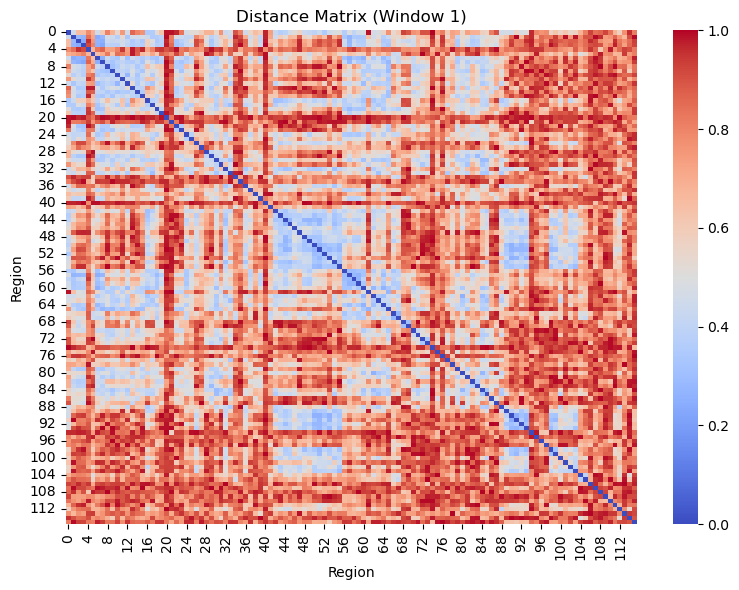

In [24]:
# === Plot sample heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(dist_tensor[0], cmap='coolwarm', vmin=0, vmax=1)
plt.title("Distance Matrix (Window 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()